# Spectral Density Estimation

This notebook estimates the density of states of a finite tight-binding Hamiltonian by applying smooth polynomial window functions across the spectrum.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a tight-binding spectral-density estimation task.

**QSVT implementation.** It uses Gaussian-window polynomial filters over shifted spectral centers. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact eigenvalue windows validate the trace-density curve. At scale, QSVT-style spectral windows can estimate densities or local spectral weights from block-encoded operators without full diagonalization.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import eigh_hermitian
from qsvt.hamiltonians import tight_binding_chain
from qsvt.matrix_functions import design_gaussian_window_polynomial

H = tight_binding_chain(32)
evals, _ = eigh_hermitian(H)
scale = np.max(np.abs(evals))
scaled = evals / scale

centers = np.linspace(-0.95, 0.95, 60)
sigma = 0.10
degree = 26
density_poly = []
density_exact = []
for center in centers:
    target = lambda x, c=center: np.exp(-0.5 * ((x - c) / sigma) ** 2)
    coeffs = design_gaussian_window_polynomial(
        center=center, width=sigma, degree=degree
    )
    density_poly.append(np.mean(eval_polynomial(coeffs, scaled)))
    density_exact.append(np.mean(target(scaled)))

curve_error = np.linalg.norm(
    np.array(density_poly) - np.array(density_exact)
) / np.linalg.norm(density_exact)
curve_error

np.float64(0.0019122824182919095)

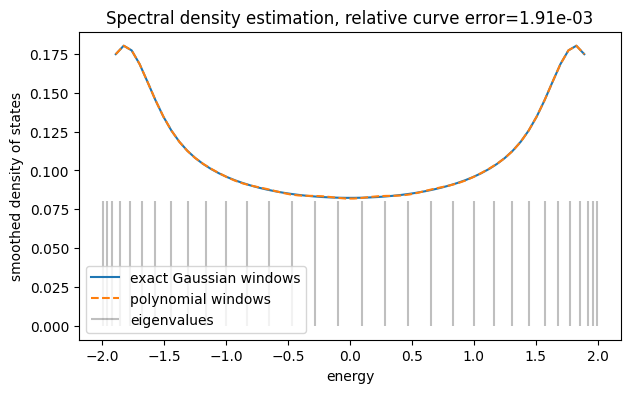

In [2]:
plt.figure(figsize=(7, 4))
plt.plot(centers * scale, density_exact, label="exact Gaussian windows")
plt.plot(centers * scale, density_poly, "--", label="polynomial windows")
plt.vlines(evals, 0, 0.08, color="black", alpha=0.25, label="eigenvalues")
plt.xlabel("energy")
plt.ylabel("smoothed density of states")
plt.title(f"Spectral density estimation, relative curve error={curve_error:.2e}")
plt.legend()
plt.show()